In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
data = pd.read_csv("ai_job_dataset.csv")
data.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [3]:
data.shape

(15000, 19)

In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [5]:
data.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [6]:
data.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

In [7]:
data.isnull().sum()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


In [8]:
data.isnull().sum()

,0
job_id,0
job_title,0
salary_usd,0
salary_currency,0
experience_level,0
employment_type,0
company_location,0
company_size,0
employee_residence,0
remote_ratio,0


In [9]:
data.duplicated().sum()

np.int64(0)

In [10]:
data['posting_date'] = pd.to_datetime(data['posting_date'])
data['application_deadline'] = pd.to_datetime(data['application_deadline'])

In [11]:
data.dtypes

,0
job_id,object
job_title,object
salary_usd,int64
salary_currency,object
experience_level,object
employment_type,object
company_location,object
company_size,object
employee_residence,object
remote_ratio,int64


In [12]:
data.nunique()

,0
job_id,15000
job_title,20
salary_usd,14315
salary_currency,3
experience_level,4
employment_type,4
company_location,20
company_size,3
employee_residence,20
remote_ratio,3


2. How many AI jobs are in the dataset?

In [13]:
total_jobs = data['job_id'].nunique()

print("Total AI Jobs:", total_jobs)

Total AI Jobs: 15000


3. Average, minimum and maximum salary

In [14]:
average_salary = data['salary_usd'].mean()
minimum_salary = data['salary_usd'].min()
maximum_salary = data['salary_usd'].max()

print("Average Salary: $", round(average_salary, 2))
print("Minimum Salary: $", round(minimum_salary, 2))
print("Maximum Salary: $", round(maximum_salary, 2))

Average Salary: $ 115348.97
Minimum Salary: $ 32519
Maximum Salary: $ 399095


4. Which job titles have the highest salaries?

In [15]:
top_job_titles = (
    data.groupby('job_title')['salary_usd']
      .mean()
      .sort_values(ascending=False)
      .head(10)
)

print(top_job_titles)

job_title
AI Specialist                120570.758242
Machine Learning Engineer    118827.919689
Head of AI                   118542.968627
AI Research Scientist        117897.925926
AI Architect                 117436.513619
Robotics Engineer            116470.793149
Principal Data Scientist     116305.219346
Research Scientist           116066.502695
Data Engineer                115970.720961
Data Scientist               115819.008333
Name: salary_usd, dtype: float64


In [16]:
top_job_titles.reset_index(name='Average Salary')

,job_title,Average Salary
0,AI Specialist,120570.758242
1,Machine Learning Engineer,118827.919689
2,Head of AI,118542.968627
3,AI Research Scientist,117897.925926
4,AI Architect,117436.513619
5,Robotics Engineer,116470.793149
6,Principal Data Scientist,116305.219346
7,Research Scientist,116066.502695
8,Data Engineer,115970.720961
9,Data Scientist,115819.008333


5. How does salary change with experience?

In [17]:
data['experience_level'].value_counts()

,count
experience_level,
MI,3781
EX,3760
SE,3741
EN,3718


average salary

In [18]:
salary_by_experience = (
    data.groupby('experience_level')['salary_usd']
      .mean()
      .sort_values(ascending=False)
)

print(salary_by_experience)

experience_level
EX    187723.647340
SE    122187.657845
MI     87955.471833
EN     63133.377084
Name: salary_usd, dtype: float64


make a chart

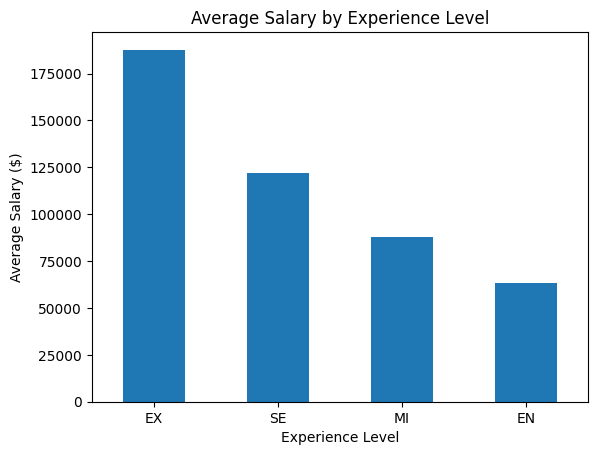

In [19]:
salary_by_experience.plot(kind='bar')

plt.title("Average Salary by Experience Level")
plt.xlabel("Experience Level")
plt.ylabel("Average Salary ($)")
plt.xticks(rotation=0)
plt.show()

6. Which countries have the most AI jobs?

In [20]:
top_countries = (
    data['company_location']
      .value_counts()
      .head(10)
)

print(top_countries)

company_location
Germany      814
Denmark      778
Canada       769
France       769
Austria      765
Singapore    764
China        763
India        754
Sweden       752
Israel       751
Name: count, dtype: int64


In [21]:
top_countries.reset_index(name='Number of Jobs')

,company_location,Number of Jobs
0,Germany,814
1,Denmark,778
2,Canada,769
3,France,769
4,Austria,765
5,Singapore,764
6,China,763
7,India,754
8,Sweden,752
9,Israel,751


7. Which industries hire the most?

In [22]:
top_industries = (
    data['industry']
      .value_counts()
      .head(10)
)

print(top_industries)

industry
Retail                1063
Media                 1045
Automotive            1020
Consulting            1020
Technology            1011
Real Estate           1007
Government             998
Transportation         997
Telecommunications     997
Healthcare             997
Name: count, dtype: int64


In [23]:
top_industries.reset_index(name='Number of Jobs')

,industry,Number of Jobs
0,Retail,1063
1,Media,1045
2,Automotive,1020
3,Consulting,1020
4,Technology,1011
5,Real Estate,1007
6,Government,998
7,Transportation,997
8,Telecommunications,997
9,Healthcare,997


8. What education level is most common?

In [24]:
education_counts = data['education_required'].value_counts()

print(education_counts)

education_required
Bachelor     3789
Associate    3785
Master       3748
PhD          3678
Name: count, dtype: int64


9. How common are remote jobs?

In [25]:
remote_counts = data['remote_ratio'].value_counts().sort_index()

print(remote_counts)

remote_ratio
0      5075
50     5005
100    4920
Name: count, dtype: int64


In [26]:
remote_percentage = (
    data['remote_ratio']
      .value_counts(normalize=True)
      .sort_index() * 100
)

print(remote_percentage.round(2))

remote_ratio
0      33.83
50     33.37
100    32.80
Name: proportion, dtype: float64


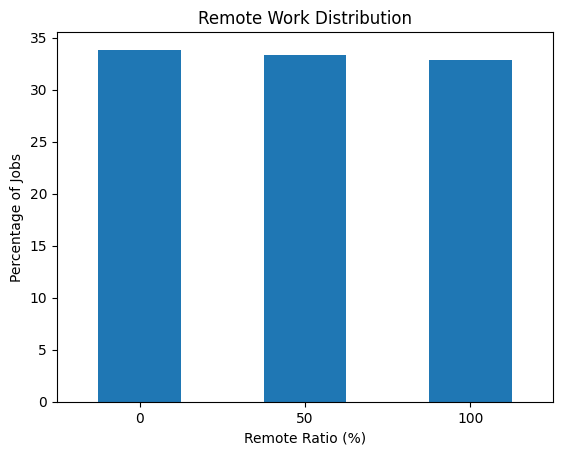

In [27]:
remote_percentage.plot(kind='bar')

plt.title("Remote Work Distribution")
plt.xlabel("Remote Ratio (%)")
plt.ylabel("Percentage of Jobs")
plt.xticks(rotation=0)
plt.show()

10. Which skills are most demanded?

In [28]:
data['required_skills'].head()

,required_skills
0,"Tableau, PyTorch, Kubernetes, Linux, NLP"
1,"Deep Learning, AWS, Mathematics, Python, Docker"
2,"Kubernetes, Deep Learning, Java, Hadoop, NLP"
3,"Scala, SQL, Linux, Python"
4,"MLOps, Java, Tableau, Python"


In [29]:
skills = data['required_skills'].dropna().str.split(',')

In [30]:
all_skills = skills.explode()

all_skills = all_skills.str.strip()

In [31]:
skill_counts = all_skills.value_counts()

print(skill_counts.head(10))

required_skills
Python        4450
SQL           3407
TensorFlow    3022
Kubernetes    3009
Scala         2794
PyTorch       2777
Linux         2705
Git           2631
Java          2578
GCP           2442
Name: count, dtype: int64


In [32]:
top_skills = skill_counts.head(10)

print(top_skills)

required_skills
Python        4450
SQL           3407
TensorFlow    3022
Kubernetes    3009
Scala         2794
PyTorch       2777
Linux         2705
Git           2631
Java          2578
GCP           2442
Name: count, dtype: int64


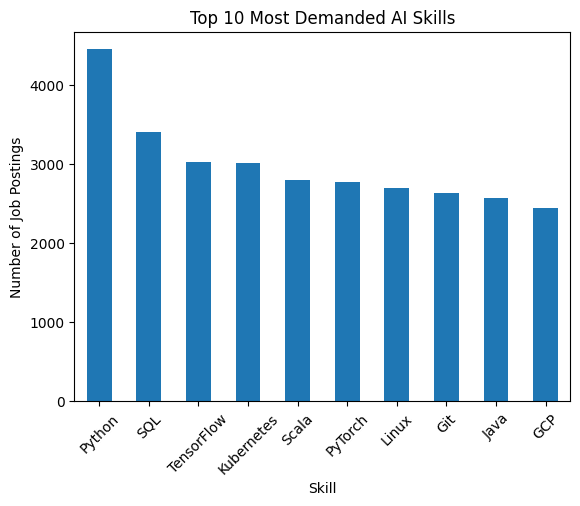

In [33]:
top_skills.plot(kind='bar')

plt.title("Top 10 Most Demanded AI Skills")
plt.xlabel("Skill")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=45)
plt.show()

11. Does more experience lead to higher salary?

In [34]:
correlation = data['years_experience'].corr(data['salary_usd'])

print("Correlation:", round(correlation, 2))

Correlation: 0.74


## 12. Key Findings

In [35]:
import pandas as pd

data = pd.read_csv("ai_job_dataset.csv")

print("KEY FINDINGS OF AI JOB MARKET ANALYSIS")
print("--------------------------------------")

print("1. Total number of AI jobs:", len(data))

print("2. Average salary: $", round(data['salary_usd'].mean(), 2))

print("3. Minimum salary: $", round(data['salary_usd'].min(), 2))

print("4. Maximum salary: $", round(data['salary_usd'].max(), 2))

print("5. Highest-paying job title:",
      data.groupby('job_title')['salary_usd'].mean().idxmax())

print("6. Highest-paying experience level:",
      data.groupby('experience_level')['salary_usd'].mean().idxmax())

print("7. Country with the most jobs:",
      data['company_location'].value_counts().idxmax())

print("8. Most common education level:",
      data['education_required'].value_counts().idxmax())

print("9. Most common employment type:",
      data['employment_type'].value_counts().idxmax())

print("10. Correlation between experience and salary:",
      round(data['years_experience'].corr(data['salary_usd']), 2))

KEY FINDINGS OF AI JOB MARKET ANALYSIS
--------------------------------------
1. Total number of AI jobs: 15000
2. Average salary: $ 115348.97
3. Minimum salary: $ 32519
4. Maximum salary: $ 399095
5. Highest-paying job title: AI Specialist
6. Highest-paying experience level: EX
7. Country with the most jobs: Germany
8. Most common education level: Bachelor
9. Most common employment type: FT
10. Correlation between experience and salary: 0.74
